# HW2P2: Image Recognition and Verification

This is the second homework  in 11785: Introduction to Deep Learning. We are trying to tackle the problem of Image Verification. For this, we will need to first train our own CNN model to tackle the problem of classification, consisting of 8631 identities. Using this, we get the face embeddings for different pairs of images and try to identify if the pair of face matches or not.

# Libraries

In [ ]:
gc.collect() # These commands help you when you face CUDA OOM error
torch.cuda.empty_cache()

In [1]:
!nvidia-smi # Run this to see what GPU you have

Thu Oct 17 23:56:19 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.29.06              Driver Version: 545.29.06    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA RTX A6000               Off | 00000000:01:00.0 Off |                  Off |
| 36%   66C    P2             290W / 300W |  48510MiB / 49140MiB |     98%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
import torch
torch.cuda.is_available()
# torch.cuda.device_count() 




True

In [3]:
# !pip install wandb --quiet # Install WandB
# !pip install pytorch_metric_learning --quiet #Install the Pytorch Metric Library

In [4]:
import torch
from torchsummary import summary
import torchvision
from torchvision import transforms
import torch.nn.functional as F
from torchvision.transforms import v2
from torch.utils.data import default_collate
import os
import gc
from tqdm import tqdm
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn import metrics as mt
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import glob
import wandb
import matplotlib.pyplot as plt
from pytorch_metric_learning import samplers
import csv

from functools import partial
from typing import Any, Callable, List, Optional, Sequence




import torch
from torch import nn, Tensor
from torch.nn import functional as F



DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", DEVICE)


Device:  cuda


# Kaggle

In [5]:
# TODO: Use the same Kaggle code from HW1P2
!pip install --upgrade --force-reinstall --no-deps kaggle

DEPRECATION: Loading egg at /home/ljc/miniconda3/envs/sbit/lib/python3.11/site-packages/einops-0.8.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /home/ljc/miniconda3/envs/sbit/lib/python3.11/site-packages/ninja-1.11.1.1-py3.11-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
  Using cached kaggle-1.6.17-py3-none-any.whl
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.6.17
    Uninstalling kaggle-1.6.17:
      Successfully uninstalled kaggle-1.6.17


In [6]:
import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
#kaggle account and API
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w+") as f:
    f.write('{"username":"angelanqiya","key":"9b813d342c3b556cafd2689211d153ef"}')


os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)



# Config

In [7]:
config = {
    'batch_size': 512, # Increase this if your GPU can handle it
    'lr': 1e-3,
    'epochs': 80, # 20 epochs is recommended ONLY for the early submission - you will have to train for much longer typically.
    'num_classes': 8631,
    'weight_decay': 0.05,
    'drop':0.2,
    'layer_scale_init_value':1e-6,
    'data_dir': "/home/ljc/aq/hw2/p2/11-785-f24-hw2p2-verification/cls_data", #TODO
    'data_ver_dir': "/home/ljc/aq/hw2/p2/11-785-f24-hw2p2-verification/ver_data", #TODO
    'checkpoint_dir': "/home/ljc/aq/hw2/p2/11-785-f24-hw2p2-verification" #TODO
    # Include other parameters as needed.
}

# Dataset

## Dataset Class for doing Image Verification

In [8]:
class ImagePairDataset(torch.utils.data.Dataset):

    def __init__(self, data_dir, csv_file, transform):
        self.data_dir = data_dir
        self.transform = transform
        self.pairs = []
        if csv_file.endswith('.csv'):
            with open(csv_file, 'r') as f:
                reader = csv.reader(f)
                for i, row in enumerate(reader):
                    if i == 0:
                        continue
                    else:
                        self.pairs.append(row)
        else:
            with open(csv_file, 'r') as f:
                for line in f.readlines():
                    self.pairs.append(line.strip().split(' '))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        img_path1, img_path2, match = self.pairs[idx]
        img1 = Image.open(os.path.join(self.data_dir, img_path1))
        img2 = Image.open(os.path.join(self.data_dir, img_path2))
        return self.transform(img1), self.transform(img2), int(match)

In [9]:
class TestImagePairDataset(torch.utils.data.Dataset):

    def __init__(self, data_dir, csv_file, transform):
        self.data_dir = data_dir
        self.transform = transform
        self.pairs = []
        if csv_file.endswith('.csv'):
            with open(csv_file, 'r') as f:
                reader = csv.reader(f)
                for i, row in enumerate(reader):
                    if i == 0:
                        continue
                    else:
                        self.pairs.append(row)
        else:
            with open(csv_file, 'r') as f:
                for line in f.readlines():
                    self.pairs.append(line.strip().split(' '))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        img_path1, img_path2 = self.pairs[idx]
        img1 = Image.open(os.path.join(self.data_dir, img_path1))
        img2 = Image.open(os.path.join(self.data_dir, img_path2))
        return self.transform(img1), self.transform(img2)

## Create Dataloaders for Image Recognition

### cutmix/mixup

In [10]:
cutmix = v2.CutMix(num_classes=config['num_classes'])
mixup = v2.MixUp(num_classes=config['num_classes'])
cutmix_or_mixup = v2.RandomChoice([cutmix, mixup])


def collate_fn(batch):
    return cutmix_or_mixup(*default_collate(batch))

In [11]:
data_dir = config['data_dir']
train_dir = os.path.join(data_dir)

train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'dev')

# train transforms
train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(224),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomRotation(30),
    torchvision.transforms.RandomErasing(p=0.25),
    torchvision.transforms.ColorJitter(brightness=0.1, contrast=0.1,saturation=0.1,hue=0.1),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

# val transforms
val_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(224),
    torchvision.transforms.ToTensor(),
     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])


# get datasets
train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = torchvision.datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                            batch_size=config["batch_size"],
                                            shuffle=True,
                                            pin_memory=True,
                                            num_workers=8,
                                            sampler=None,collate_fn=collate_fn)
val_loader = torch.utils.data.DataLoader(val_dataset,
                                          batch_size=config["batch_size"],
                                          shuffle=False,
                                          num_workers=4)

In [12]:
data_dir = config['data_ver_dir']

# get datasets

# TODO: Add your validation pair txt file
val_pairs = '11-785-f24-hw2p2-verification/val_pairs.txt'

pair_dataset = ImagePairDataset(data_dir, csv_file=val_pairs, transform=val_transforms)
pair_dataloader = torch.utils.data.DataLoader(pair_dataset,
                                              batch_size=config["batch_size"],
                                              shuffle=False,
                                              pin_memory=True,
                                              num_workers=4)


# TODO: Add your validation pair txt file
test_pairs = '11-785-f24-hw2p2-verification/test_pairs.txt'
test_pair_dataset = TestImagePairDataset(data_dir, csv_file=test_pairs, transform=val_transforms)
test_pair_dataloader = torch.utils.data.DataLoader(test_pair_dataset,
                                              batch_size=config["batch_size"],
                                              shuffle=False,
                                              pin_memory=True,
                                              num_workers=4)

# EDA and Viz

In [13]:
# Double-check your dataset/dataloaders work as expected

print("Number of classes    : ", len(train_dataset.classes))
print("No. of train images  : ", train_dataset.__len__())
print("Shape of image       : ", train_dataset[0][0].shape)
print("Batch size           : ", config['batch_size'])
print("Train batches        : ", train_loader.__len__())
print("Val batches          : ", val_loader.__len__())

# Feel free to print more things if needed

Number of classes    :  8631
No. of train images  :  431549
Shape of image       :  torch.Size([3, 224, 224])
Batch size           :  512
Train batches        :  843
Val batches          :  85


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

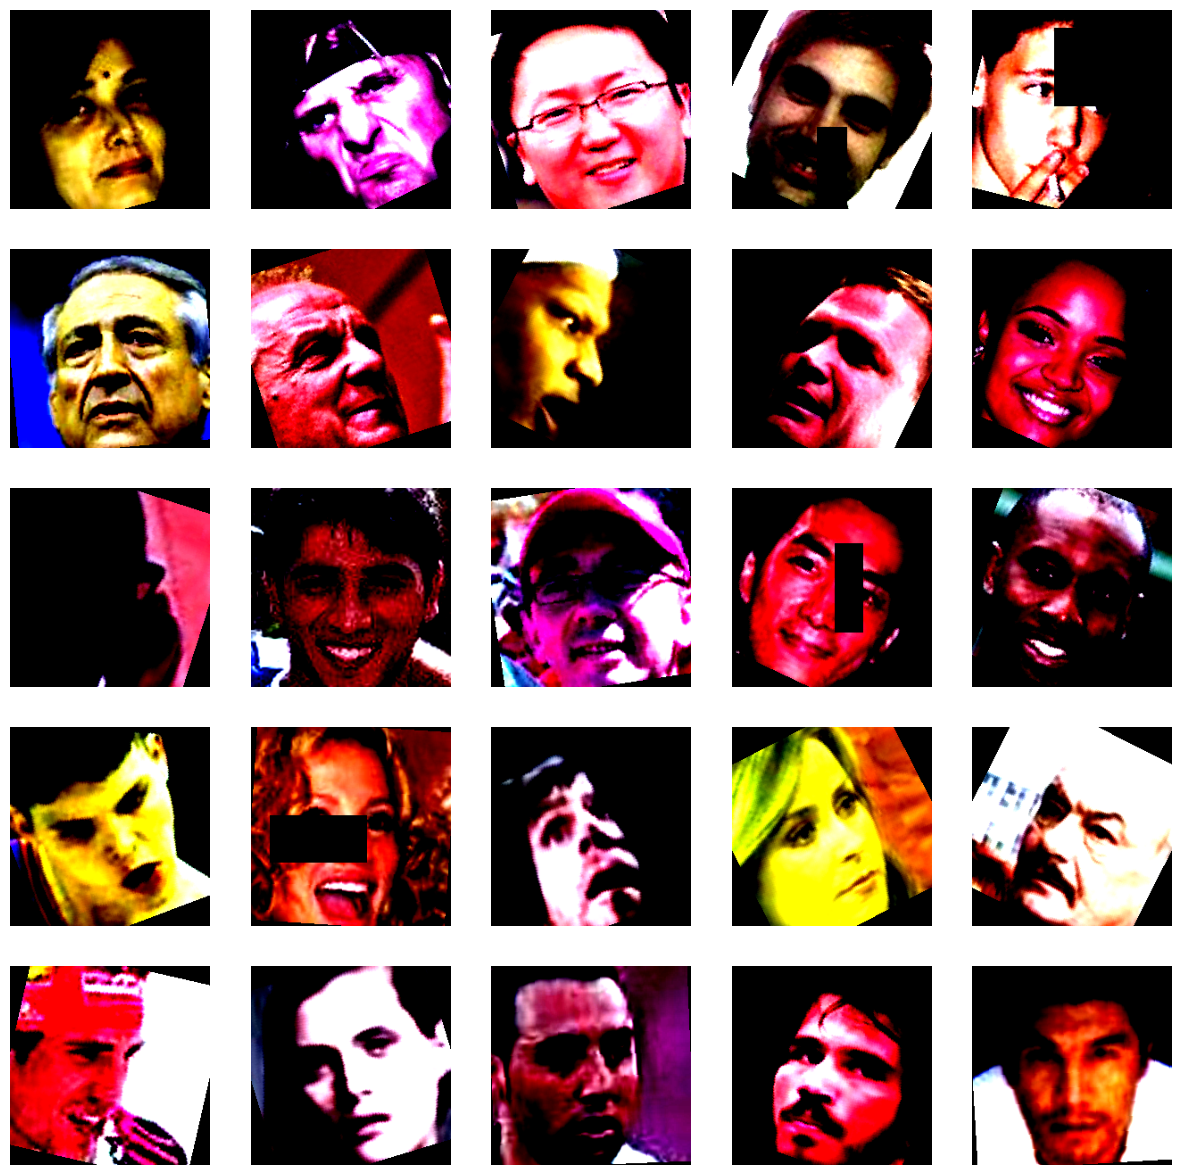

In [14]:
# Visualize a few images in the dataset

"""
You can write your own code, and you don't need to understand the code
It is highly recommended that you visualize your data augmentation as sanity check
"""

r, c    = [5, 5]
fig, ax = plt.subplots(r, c, figsize= (15, 15))

k       = 0
dtl     = torch.utils.data.DataLoader(
    dataset     = torchvision.datasets.ImageFolder(train_dir, transform= train_transforms), # dont wanna see the images with transforms
    batch_size  = config['batch_size'],
    shuffle     = True)

for data in dtl:
    x, y = data

    for i in range(r):
        for j in range(c):
            img = x[k].numpy().transpose(1, 2, 0)
            ax[i, j].imshow(img)
            ax[i, j].axis('off')
            k+=1
    break

del dtl

# Model Architecture

FAQ:

**What's a very low early deadline architecture (mandatory early submission)**?

- The very low early deadline architecture is a 5-layer CNN. Keep in mind the parameter limit is 18M.
- The first convolutional layer has 64 channels, kernel size 7, and stride 4. The next three have 128, 256, 512 and 1024 channels. Each have kernel size 3 and stride 2. Documentation to make convolutional layers: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- Think about strided convolutions from the lecture, as convolutions with stride = 1 and downsampling. For strided convolution, what padding do you need for preserving the spatial resolution? (Hint => padding = kernel_size // 2) - Think why?
- Each convolutional layer is accompanied by a Batchnorm and ReLU layer.
- Finally, you want to average pool over the spatial dimensions to reduce them to 1 x 1. Use AdaptiveAvgPool2d. Documentation for AdaptiveAvgPool2d: https://pytorch.org/docs/stable/generated/torch.nn.AdaptiveAvgPool2d.html
- Then, remove (Flatten?) these trivial 1x1 dimensions away.
Look through https://pytorch.org/docs/stable/nn.html


**Why does a very simple network have 4 convolutions**?

Input images are 112x112. Note that each of these convolutions downsample. Downsampling 2x effectively doubles the receptive field, increasing the spatial region each pixel extracts features from. Downsampling 32x is standard for most image models.

**Why does a very simple network have high channel sizes**?

Every time you downsample 2x, you do 4x less computation (at same channel size). To maintain the same level of computation, you 2x increase # of channels, which increases computation by 4x. So, balances out to same computation. Another intuition is - as you downsample, you lose spatial information. We want to preserve some of it in the channel dimension.

**What is return_feats?**

It essentially returns the second-to-last-layer features of a given image. It's a "feature encoding" of the input image, and you can use it for the verification task. You would use the outputs of the final classification layer for the classification task. You might also find that the classification outputs are sometimes better for verification too - try both.

In [15]:
import torch.nn as nn

In [16]:
# TODO: Fill out the model definition below

class Network(torch.nn.Module):

    def __init__(self, num_classes=8631):
        super().__init__()

        self.backbone = torch.nn.Sequential(
            # First convolutional block
            nn.Conv2d(3, 64, kernel_size=7, stride=4, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            # Second convolutional block
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            # Third convolutional block
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            # Fourth convolutional block
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            
    
            
            # Fifth convolutional block
            nn.Conv2d(512, 1024, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            # Adaptive pooling to reduce the spatial dimensions to 1x1
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
            )

        self.cls_layer = nn.Linear(1024, num_classes)

    def forward(self, x):
            # TODO:
            # pass the input to the backbone network
            feats = self.backbone(x)
            # pass the reshaped output to the classification layer
            out = self.cls_layer(feats)
            # return the output

            return {"feats": feats, "out": out}

# # Initialize your model
# model = Network().to(DEVICE)
# summary(model, (3, 112, 112))

### Resnet

In [17]:
# class ResidualBlock(nn.Module):
#     def __init__(self, in_channels, out_channels, downsample = None):
#         super(ResidualBlock, self).__init__()
#         self.conv1 = nn.Sequential(
#                         nn.Conv2d(in_channels, out_channels, kernel_size = 3, stride = 1, padding = 1),
#                         nn.BatchNorm2d(out_channels),
#                         nn.ReLU())
#         self.conv2 = nn.Sequential(
#                         nn.Conv2d(out_channels, out_channels, kernel_size = 3, stride = 1, padding = 1),
#                         nn.BatchNorm2d(out_channels))
#         self.downsample = downsample
#         self.relu = nn.ReLU()
#         self.out_channels = out_channels

#     def forward(self, x):
#         residual = x
#         out = self.conv1(x)
#         out = self.conv2(out)
#         if self.downsample:
#             residual = self.downsample(x)
#         out += residual
#         out = self.relu(out)
#         return out

#### bottleneck block

In [18]:
def conv3x3(in_planes: int, out_planes: int, stride: int = 1, groups: int = 1, dilation: int = 1) -> nn.Conv2d:
    """3x3 convolution with padding"""
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        groups=groups,
        bias=False,
        dilation=dilation,
    )


def conv1x1(in_planes: int, out_planes: int, stride: int = 1) -> nn.Conv2d:
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


In [19]:
class BasicBlock(nn.Module):
    expansion: int = 1

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError("BasicBlock only supports groups=1 and base_width=64")
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out



In [20]:
class Bottleneck(nn.Module):
    # Bottleneck in torchvision places the stride for downsampling at 3x3 convolution(self.conv2)
    # while original implementation places the stride at the first 1x1 convolution(self.conv1)
    # according to "Deep residual learning for image recognition" https://arxiv.org/abs/1512.03385.
    # This variant is also known as ResNet V1.5 and improves accuracy according to
    # https://ngc.nvidia.com/catalog/model-scripts/nvidia:resnet_50_v1_5_for_pytorch.

    expansion: int = 4

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.0)) * groups
        # Both self.conv2 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [21]:
from typing import Type, Union, List, Optional, Callable

class ResNet(nn.Module):
    def __init__(
        self,
        block: Type[Union[BasicBlock, Bottleneck]],
        layers: List[int],
        num_classes: int = 8631,
        zero_init_residual: bool = False,
        groups: int = 1,
        width_per_group: int = 64,
        replace_stride_with_dilation: Optional[List[bool]] = None,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            # each element in the tuple indicates if we should replace
            # the 2x2 stride with a dilated convolution instead
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError(
                "replace_stride_with_dilation should be None "
                f"or a 3-element tuple, got {replace_stride_with_dilation}"
            )
        self.groups = groups
        self.base_width = width_per_group
        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2, dilate=replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2, dilate=replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2, dilate=replace_stride_with_dilation[2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck) and m.bn3.weight is not None:
                    nn.init.constant_(m.bn3.weight, 0)  # type: ignore[arg-type]
                elif isinstance(m, BasicBlock) and m.bn2.weight is not None:
                    nn.init.constant_(m.bn2.weight, 0)  # type: ignore[arg-type]

    def _make_layer(
        self,
        block: Type[Union[BasicBlock, Bottleneck]],
        planes: int,
        blocks: int,
        stride: int = 1,
        dilate: bool = False,
    ) -> nn.Sequential:
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(
            block(
                self.inplanes, planes, stride, downsample, self.groups, self.base_width, previous_dilation, norm_layer
            )
        )
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(
                block(
                    self.inplanes,
                    planes,
                    groups=self.groups,
                    base_width=self.base_width,
                    dilation=self.dilation,
                    norm_layer=norm_layer,
                )
            )

        return nn.Sequential(*layers)

    def _forward_impl(self, x: Tensor) -> Tensor:
        # See note [TorchScript super()]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        

        return x
    
    
    def forward(self, x):
            feats = self._forward_impl(x)
            # pass the reshaped output to the classification layer
            out = self.fc(feats)
            # return the output
            return {"feats": feats, "out": out}

In [22]:
# class ResNet(nn.Module):
#     def __init__(self, block, layers,
#                  block_sizes = [64,128, 256, 512],
#                 num_of_blocks = [3, 3, 6, 3], 
#                 num_classes = 8631):
#         super(ResNet, self).__init__()
#         self.inplanes = 64
#         self.conv1 = nn.Sequential(
#                         nn.Conv2d(3, 64, kernel_size = 7, stride = 2, padding = 3),
#                         nn.BatchNorm2d(64),
#                         nn.ReLU(),
#                         nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)
#                         )
        
#         self.layer0 = self._make_layer(block, 64, layers[0], stride = 1)
#         # self.layer1 = self._make_layer(block, 128, layers[1], stride = 2)
#         # self.layer2 = self._make_layer(block, 256, layers[2], stride = 2)
#         # self.layer3 = self._make_layer(block, 512, layers[3], stride = 2)
        
#         for i in range(1, len(block_sizes)):
#             setattr(self, f"layer{i}", self._make_layer(block, block_sizes[i], num_of_blocks[i], stride = 2))
#         self.avgpool = nn.AvgPool2d(7, stride=1)
#         self.fc = nn.Linear(block_sizes[-1], num_classes)
        
            
#         # weight initialization
#         for m in self.modules():
#             if isinstance(m, nn.Conv2d):
#                 nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
#             elif isinstance(m, nn.BatchNorm2d):
#                 nn.init.constant_(m.weight, 1)
#                 nn.init.constant_(m.bias, 0)


#     def _make_layer(self, block, planes, blocks, stride=1):
#         downsample = None
#         if stride != 1 or self.inplanes != planes:

#             downsample = nn.Sequential(
#                 nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride),
#                 nn.BatchNorm2d(planes),
#             )
#         layers = []
#         layers.append(block(self.inplanes, planes, stride, downsample))
#         self.inplanes = planes
#         for i in range(1, blocks):
#             layers.append(block(self.inplanes, planes))

#         return nn.Sequential(*layers)

#     def forward(self, x):
#         x = self.conv1(x)
#         x = self.maxpool(x)
#         x = self.layer0(x)
#         x = self.layer1(x)
#         x = self.layer2(x)
#         x = self.layer3(x)

#         x = self.avgpool(x)
#         x = x.view(x.size(0), -1)
#         x = self.fc(x)

#         return x

## ConvNet

In [23]:
from functools import partial
from typing import Any, Callable, List, Optional, Sequence

import torch
from torch import nn, Tensor
from torch.nn import functional as F

from traitlets.traitlets import Float
from torch._C import ThroughputBenchmark
from torchvision.ops import StochasticDepth


In [24]:
# class ConvNeXtBlock(nn.Module):
#     def __init__(self, dim, drop_path_rate=0., layer_scale_init_value=1e-6):
#         super().__init__()
#         # Depthwise convolution (preserves spatial dimensions)
#         self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        
#         # BatchNorm 
#         self.norm = nn.BatchNorm2d(dim)
        
#         # Pointwise convolutions
#         self.pwconv1 = nn.Conv2d(dim, 4 * dim, kernel_size=1)
#         self.act = nn.GELU()
#         self.pwconv2 = nn.Conv2d(4 * dim, dim, kernel_size=1)
        
#         # Layer scale parameter gamma (optional)
#         self.gamma = nn.Parameter(
#             layer_scale_init_value * torch.ones(dim, 1, 1),
#             requires_grad=True
#         ) if layer_scale_init_value > 0 else None

#         # Stochastic depth
#         self.drop_path = nn.Dropout(drop_path_rate) if drop_path_rate > 0. else nn.Identity()

#     def forward(self, x):
#         # Save the input for the residual connection
#         shortcut = x
        
#         # Depthwise convolution, BatchNorm, and pointwise convolution
#         x = self.dwconv(x)
#         x = self.norm(x)  # Apply BatchNorm2d
#         x = self.pwconv1(x)
#         x = self.act(x)
#         x = self.pwconv2(x)
        
#         # Apply layer scaling if gamma is defined
#         if self.gamma is not None:
#             x = self.gamma * x
        
#         # Apply dropout for stochastic depth
#         x = self.drop_path(x)
        
#         # Add the residual connection
#         return shortcut + x


In [25]:
class ConvNBlock(nn.Module):
  def __init__(self, in_features, out_features, depth_prob:float, layer_scale, expansion = 4, 
               kernel_size = 7):
    super().__init__()
    
    self.block = nn.Sequential(
        nn.Conv2d(in_channels = in_features, out_channels = in_features, kernel_size = kernel_size, 
                  padding =3, groups = in_features,bias = True),
        # nn.GroupNorm(num_groups = 1, num_channels = in_features), # Layer norm
        nn.BatchNorm2d(num_features = in_features),
        nn.Conv2d(in_features, expansion*in_features, kernel_size=1),
        # nn.Linear(in_features, expansion*in_features, bias = True), # expand
        # note Conv layer with stride 1 generate same result as linear layer, but linear layer need permutation
        # activation_functions[activation],
        nn.GELU(),
        nn.Conv2d(expansion*in_features, out_features, kernel_size=1)
        # nn.Linear(expansion*in_features, out_features, bias =True) # shrink
    )

    self.layer_scale = nn.Parameter(torch.ones(out_features, 1, 1)*layer_scale)
    self.stochastic_depth = StochasticDepth(depth_prob, mode = 'row')
  
  def forward(self, x):
    res = self.layer_scale*self.block(x)
    res = self.stochastic_depth(res)
    res += x
    return res

In [26]:
# class ConvNeXt(nn.Module):
#     def __init__(self, in_chans=3, num_classes=8631, 
#                  depths=[3, 3, 9, 3], dims=[96,192,384,768], 
#                  drop_path_rate=0., layer_scale_init_value=1e-6, head_init_scale=1.):
#         super().__init__()
#         self.stages = nn.ModuleList()
#         # prev_blocks = 0
#         # drop_stage = torch.linspace(0, drop_path_rate, sum(depths))

#         # Stem layers
#         self.downsample_layers = nn.ModuleList()
#         stem = nn.Sequential(
#             nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4),
#             nn.BatchNorm2d(dims[0]),
#         )
#         self.downsample_layers.append(stem)

#         # # Intermediate downsampling layers
#         # for i in range(4):
#         #     downsample_layer = nn.Sequential(
#         #         nn.BatchNorm2d(dims[i-1], eps=1e-6),
#         #         nn.Conv2d(dims[i-1], dims[i], kernel_size=2, stride=2),
                
#         #     )
            
#         #     self.downsample_layers.append(downsample_layer)

#         #     self.stages.append(nn.Sequential(
#         #         *[ConvNeXtBlock(dims[i], drop_stage[prev_blocks+j], layer_scale_init_value) for j in range(depths[i])]
#         #     ))
#         #     prev_blocks += depths[i]

#         # # Global average pooling and classification head
#         # self.norm = nn.BatchNorm2d(dims[-1], eps=1e-6)
#         # self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

#         # # Fix the input dimension for the classification head
#         # self.head = nn.Linear(dims[-1], num_classes)  
        
#         # Construct stages with downsampling
#         dp_rates = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
#         cur = 0
#         for i in range(len(depths)):
#             stage = self._make_stage(
#                 block=ConvNeXtBlock,
#                 in_features=dims[i],
#                 out_features=dims[i + 1] if i < len(dims) - 1 else dims[i],
#                 depth=depths[i],
#                 drop_path_rates=dp_rates[cur:cur + depths[i]],
#                 layer_scale_init_value=layer_scale_init_value,
#                 downsample=(i < len(dims) - 1)  # Add downsample for all except the last stage
#             )
#             self.downsample_layers.append(stage['downsample'])
#             self.stages.append(stage['blocks'])
#             cur += depths[i]

#         # Global average pooling and classification head
#         self.norm = nn.BatchNorm2d(dims[-1], eps=1e-6)
#         self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
#         self.head = nn.Linear(dims[-1], num_classes)

#         # Initialize weights
#         self.apply(self._init_weights)
#         self.head.weight.data.mul_(head_init_scale)
#         self.head.bias.data.mul_(head_init_scale)

#     def _make_stage(self, block, in_features, out_features, depth, drop_path_rates, layer_scale_init_value, downsample):
#         # Create blocks
#         blocks = nn.Sequential(
#             *[block(
#                 dim=in_features,
#                 drop_path_rate=drop_path_rates[i],
#                 layer_scale_init_value=layer_scale_init_value
#             ) for i in range(depth)]
#         )
        
#         # Create downsampling layer if needed
#         downsample_layer = nn.Sequential(
#             nn.BatchNorm2d(in_features),
#             nn.Conv2d(in_features, out_features, kernel_size=2, stride=2)
#         ) if downsample else nn.Identity()
        
#         return {'blocks': blocks, 'downsample': downsample_layer}


#         # Initialize weights
#         self.apply(self._init_weights)
#         self.head.weight.data.mul_(head_init_scale)
#         self.head.bias.data.mul_(head_init_scale)

#     def _init_weights(self, m):
#         if isinstance(m, (nn.Conv2d, nn.Linear)):
#             nn.init.trunc_normal_(m.weight, std=0.02)
#             nn.init.constant_(m.bias, 0)

#     def forward_features(self, x):
#         for downsample_layer, stage in zip(self.downsample_layers, self.stages):
#             x = downsample_layer(x)
#             x = stage(x)
#         x = self.avgpool(x)  # Perform global average pooling
        

#         # Apply BatchNorm2d on the 4D tensor before flattening
#         x = self.norm(x)

#         # Flatten the output before passing it to the classifier
#         x = x.flatten(1)  # Flatten after BatchNorm2d
#         return x

#     def forward(self, x):
#         feats = self.forward_features(x)
#         out = self.head(feats)  # Feed the flattened features to the linear head
#         print(feats.shape)
#         return {"feats": feats, "out": out}


In [27]:
class ConvNext(nn.Module):
  def __init__(self, block, num_classes= 7000, depth_prob = 0.2 , layer_scale= 1e-6, 
               in_channel =3, stage_size = [96, 192, 384, 768], num_of_stages = [3, 3, 9, 3],
               activation = 'gelu'):
    super().__init__()
    self.depth_prob = depth_prob
    self.layer_scale = layer_scale

    self.stem = nn.Sequential(
                  nn.Conv2d(in_channel, stage_size[0], kernel_size=4, stride=4),
                  nn.BatchNorm2d(stage_size[0]),
                  )
    in_channel = stage_size[0]

    self.total_num_stages = sum(num_of_stages)

    # self.stages = nn.ModuleList(self._make_stage(block, stage_size[0],stage_size[1],num_of_stages[0]))
    self.stages = nn.ModuleList()
    
    for i in range(len(num_of_stages)-1):
       self.stages.append(self._make_stage(block, stage_size[i],stage_size[i+1], num_of_stages[i]))
      
    
    self.stages.append(self._make_stage(block, stage_size[-1],stage_size[-1], num_of_stages[-1]))
    # the last layer doesn't need downsample
    
    self.avgpool = nn.AdaptiveAvgPool2d((1,1)) # average pool over the spatial dimensions to reduce them to 1 x 1
    self.cls = nn.Linear(stage_size[-1], num_classes)
    
  
  def _make_stage(self, block, in_features, out_features, depth):
    # downsample
    
    layers = []
    
    adjusted_depth_prob = [self.depth_prob*i/(self.total_num_stages - 1.0) for i in range(depth)] 
    # adjust stochastic depth probability based on the depth 
    for i in range(depth):
      layers.append(block(in_features, in_features, adjusted_depth_prob[i],self.layer_scale))
    
    downsample = nn.Sequential(
        # nn.GroupNorm(num_groups = 1, num_channels = in_features),
        nn.BatchNorm2d(num_features = in_features),
        nn.Conv2d(in_features, out_features, kernel_size = 2, stride = 2)
    )
    layers.append(downsample)

    return nn.Sequential(*layers)


def forward(self, x):
    x = self.stem(x)
    # print('stem',x.shape)
    
    for stage in self.stages:
      x = stage(x)
      
    print(f"Shape before avgpool: {x.shape}") 
    x = self.avgpool(x)
    print(f"Shape after avgpool: {x.shape}")
    feats = torch.flatten(x, start_dim = 1)
    print(f"Shape feats: {feats.shape}")
    out = self.cls(feats)
    print(f"Shape out: {out.shape}")
    
    return {"feats": feats, "out": out}
    


In [28]:
# model = ConvNeXt(in_chans=3, num_classes=config['num_classes'], drop_path_rate=config['drop']).to(DEVICE)
model = ResNet(block = Bottleneck,layers = [3, 4, 6, 3], num_classes=8631).to(DEVICE)
# arcface_model = ArcFaceModel(model=model, embedding_size=768, num_classes=8631).to(DEVICE)

summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [29]:
# import torch

# # Assume your model is defined as `ConvNeXt` and has been initialized
# model = ConvNeXt(
#     in_chans=3,
#     num_classes=1000,  # Example: for ImageNet with 1000 classes
#     depths=[3, 3, 9, 3],
#     dims=[96, 192, 384, 768],
#     drop_path_rate=0.1,
#     layer_scale_init_value=1e-6
# )

# # Move the model to GPU if available
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# model.to(device)

# # Create a sample input tensor (batch size of 2, 3 channels, 224x224 image size)
# x = torch.randn(2, 3, 224, 224).to(device)

# # Perform forward pass through the model
# output = model(x)

# # Print the features and classification output
# print("Features (feats):", output["feats"].shape)  
# print("Features (feats) values:", output["feats"])   

# print("Classification Output (out):", output["out"].shape)  
# print("Classification Output (out) values:", output["out"])  


In [30]:
# --------------------------------------------------- #

# Defining Loss function
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.2)
# TODO: What loss do you need for a multi class classification problem and would label smoothing be beneficial here?

# --------------------------------------------------- #

# Defining Optimizer
# optimizer = torch.optim.AdamW(model.parameters(), lr = config['lr'],weight_decay=config['weight_decay']
                            #   )
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001,weight_decay=1e-3)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-3)

# Defining Scheduler
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'max',patience=3,threshold=0.001,verbose=True)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max',patience = 3, threshold = 1e-2)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60, eta_min=1e-8, verbose=True)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=5e-4)

scaler = torch.cuda.amp.GradScaler()

# Metrics

In [31]:
class AverageMeter:
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [32]:
def accuracy(output, target, topk=(1,)):
    """Computes the accuracy over the k top predictions for the specified values of k"""
    maxk = min(max(topk), output.size()[1])
    batch_size = target.size(0)
    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.reshape(1, -1).expand_as(pred))
    return [correct[:min(k, maxk)].reshape(-1).float().sum(0) * 100. / batch_size for k in topk]

In [33]:
def get_ver_metrics(labels, scores, FPRs):
    # eer and auc
    fpr, tpr, _ = mt.roc_curve(labels, scores, pos_label=1)
    roc_curve = interp1d(fpr, tpr)
    EER = 100. * brentq(lambda x : 1. - x - roc_curve(x), 0., 1.)
    AUC = 100. * mt.auc(fpr, tpr)

    # get acc
    tnr = 1. - fpr
    pos_num = labels.count(1)
    neg_num = labels.count(0)
    ACC = 100. * max(tpr * pos_num + tnr * neg_num) / len(labels)

    # TPR @ FPR
    if isinstance(FPRs, list):
        TPRs = [
            ('TPR@FPR={}'.format(FPR), 100. * roc_curve(float(FPR)))
            for FPR in FPRs
        ]
    else:
        TPRs = []

    return {
        'ACC': ACC,
        'EER': EER,
        'AUC': AUC,
        'TPRs': TPRs,
    }

# Train and Validation Function

In [34]:
def train_epoch(model, dataloader, optimizer, lr_scheduler, scaler, device, config):

    model.train()

    # metric meters
    loss_m = AverageMeter()
    acc_m = AverageMeter()

    # Progress Bar
    batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, leave=False, position=0, desc='Train', ncols=5)

    for i, (images, labels) in enumerate(dataloader):

        optimizer.zero_grad() # Zero gradients

        # send to cuda
        images = images.to(device, non_blocking=True)
        if isinstance(labels, (tuple, list)):
            targets1, targets2, lam = labels
            labels = (targets1.to(device), targets2.to(device), lam)
        else:
            labels = labels.to(device, non_blocking=True)

        # forward
        with torch.cuda.amp.autocast():  # This implements mixed precision. Thats it!
            outputs = model(images)

            # Use the type of output depending on the loss function you want to use
            loss = criterion(outputs['out'], labels)

        scaler.scale(loss).backward() # This is a replacement for loss.backward()
        scaler.step(optimizer) 
        scaler.update()
        # metrics
        loss_m.update(loss.item())
        if 'feats' in outputs:
            acc = accuracy(outputs['out'], torch.argmax(labels,dim=1))[0].item()
        else:
            acc = 0.0
        acc_m.update(acc)

        # tqdm lets you add some details so you can monitor training as you train.
        batch_bar.set_postfix(
            # acc         = "{:.04f}%".format(100*accuracy),
            acc="{:.04f}% ({:.04f})".format(acc, acc_m.avg),
            loss        = "{:.04f} ({:.04f})".format(loss.item(), loss_m.avg),
            lr          = "{:.04f}".format(float(optimizer.param_groups[0]['lr'])))

        batch_bar.update() # Update tqdm bar

    # You may want to call some schedulers inside the train function. What are these?
    if lr_scheduler is not None:
        if isinstance(lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            # Pass the average loss or accuracy to ReduceLROnPlateau
            lr_scheduler.step(acc_m.avg)  # Or pass acc_m.avg depending on your goal
        else:
            # For other schedulers that do not require metrics
            lr_scheduler.step()

    batch_bar.close()

    return acc_m.avg, loss_m.avg

In [35]:
def train_epoch(model, dataloader, optimizer, lr_scheduler, scaler, device, config):

    model.train()

    # metric meters
    loss_m = AverageMeter()
    acc_m = AverageMeter()

    # Progress Bar
    batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, leave=False, position=0, desc='Train', ncols=5)

    for i, (images, labels) in enumerate(dataloader):

        optimizer.zero_grad() # Zero gradients

        # send to cuda
        images = images.to(device, non_blocking=True)
        if isinstance(labels, (tuple, list)):
            targets1, targets2, lam = labels
            labels = (targets1.to(device), targets2.to(device), lam)
        else:
            labels = labels.to(device, non_blocking=True)

        # forward
        with torch.cuda.amp.autocast():  # This implements mixed precision. Thats it!
            outputs = model(images)

            # Use the type of output depending on the loss function you want to use
            loss = criterion(outputs['out'], labels)

        scaler.scale(loss).backward() # This is a replacement for loss.backward()
        scaler.step(optimizer) 
        scaler.update()
        # metrics
        loss_m.update(loss.item())
        if 'feats' in outputs:
            acc = accuracy(outputs['out'], torch.argmax(labels,dim=1))[0].item()
        else:
            acc = 0.0
        acc_m.update(acc)

        # tqdm lets you add some details so you can monitor training as you train.
        batch_bar.set_postfix(
            # acc         = "{:.04f}%".format(100*accuracy),
            acc="{:.04f}% ({:.04f})".format(acc, acc_m.avg),
            loss        = "{:.04f} ({:.04f})".format(loss.item(), loss_m.avg),
            lr          = "{:.04f}".format(float(optimizer.param_groups[0]['lr'])))

        batch_bar.update() # Update tqdm bar

    # You may want to call some schedulers inside the train function. What are these?
    if lr_scheduler is not None:
        if isinstance(lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            # Pass the average loss or accuracy to ReduceLROnPlateau
            lr_scheduler.step(acc_m.avg)  # Or pass acc_m.avg depending on your goal
        else:
            # For other schedulers that do not require metrics
            lr_scheduler.step()

    batch_bar.close()

    return acc_m.avg, loss_m.avg

In [36]:
@torch.no_grad()
def valid_epoch_cls(model, dataloader, device, config):

    model.eval()
    batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, position=0, leave=False, desc='Val Cls.', ncols=5)

    # metric meters
    loss_m = AverageMeter()
    acc_m = AverageMeter()

    for i, (images, labels) in enumerate(dataloader):

        # Move images to device
        images, labels = images.to(device), labels.to(device)

        # Get model outputs
        with torch.inference_mode():
            outputs = model(images)
            loss = criterion(outputs['out'], labels)

        # metrics
        acc = accuracy(outputs['out'], labels)[0].item()
        loss_m.update(loss.item())
        acc_m.update(acc)

        batch_bar.set_postfix(
            acc         = "{:.04f}% ({:.04f})".format(acc, acc_m.avg),
            loss        = "{:.04f} ({:.04f})".format(loss.item(), loss_m.avg))

        batch_bar.update()

    batch_bar.close()
    return acc_m.avg, loss_m.avg

In [37]:
gc.collect() # These commands help you when you face CUDA OOM error
torch.cuda.empty_cache()

# Verification Task

In [38]:
def valid_epoch_ver(model, pair_data_loader, device, config):

    model.eval()
    scores = []
    match_labels = []
    batch_bar = tqdm(total=len(pair_data_loader), dynamic_ncols=True, position=0, leave=False, desc='Val Veri.')
    for i, (images1, images2, labels) in enumerate(pair_data_loader):

        # match_labels = match_labels.to(device)
        images = torch.cat([images1, images2], dim=0).to(device)
        # Get model outputs
        with torch.inference_mode():
            outputs = model(images)

        feats = F.normalize(outputs['feats'], dim=1)
        feats1, feats2 = feats.chunk(2)
        similarity = F.cosine_similarity(feats1, feats2)
        scores.append(similarity.cpu().numpy())
        match_labels.append(labels.cpu().numpy())
        batch_bar.update()

    scores = np.concatenate(scores)
    match_labels = np.concatenate(match_labels)

    FPRs=['1e-4', '5e-4', '1e-3', '5e-3', '5e-2']
    metric_dict = get_ver_metrics(match_labels.tolist(), scores.tolist(), FPRs)
    print(metric_dict)

    return metric_dict['ACC']

# WandB

In [39]:
wandb.login(key="48892fbec146146324ae6560bf2f084223ecdeb6") #API Key is in your wandb account, under settings (wandb.ai/settings)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: anqiyang00 (anqiyang00-carnegie-mellon-university). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/ljc/.netrc


True

In [40]:
# Create your wandb run
run = wandb.init(
    name = "early-submission", ## Wandb creates random run names if you skip this field
    reinit = True, ### Allows reinitalizing runs when you re-run this cell
    # run_id = ### Insert specific run id here if you want to resume a previous run
    # resume = "must" ### You need this to resume previous runs, but comment out reinit = True when using this
    project = "hw2p2-ablations", ### Project should be created in your wandb account
    config = config ### Wandb Config for your run
)

# Checkpointing and Loading Model

In [41]:
# Uncomment the line for saving the scheduler save dict if you are using a scheduler
def save_model(model, optimizer, scheduler, metrics, epoch, path):
    torch.save(
        {'model_state_dict'         : model.state_dict(),
         'optimizer_state_dict'     : optimizer.state_dict(),
         'scheduler_state_dict'     : scheduler.state_dict(),
         'metric'                   : metrics,
         'epoch'                    : epoch},
         path)


def load_model(model, optimizer=None, scheduler=None, path='./checkpoint.pth'):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    else:
        optimizer = None
    if scheduler is not None:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    else:
        scheduler = None
    epoch = checkpoint['epoch']
    metrics = checkpoint['metric']
    return model, optimizer, scheduler, epoch, metrics

# Experiments

In [82]:
e = 0
best_valid_cls_acc = 0.0
eval_cls = True
best_valid_ret_acc = 0.0
for epoch in range(e, config['epochs']):
        # epoch
        print("\nEpoch {}/{}".format(epoch+1, config['epochs']))

        # train
        train_cls_acc, train_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler, DEVICE, config)
        curr_lr = float(optimizer.param_groups[0]['lr'])
        print("\nEpoch {}/{}: \nTrain Cls. Acc {:.04f}%\t Train Cls. Loss {:.04f}\t Learning Rate {:.04f}".format(epoch + 1, config['epochs'], train_cls_acc, train_loss, curr_lr))
        metrics = {
            'train_cls_acc': train_cls_acc,
            'train_loss': train_loss,
        }
        # classification validation
        if eval_cls:
            valid_cls_acc, valid_loss = valid_epoch_cls(model, val_loader, DEVICE, config)
            print("Val Cls. Acc {:.04f}%\t Val Cls. Loss {:.04f}".format(valid_cls_acc, valid_loss))
            metrics.update({
                'valid_cls_acc': valid_cls_acc,
                'valid_loss': valid_loss,
            })

        # retrieval validation
        valid_ret_acc = valid_epoch_ver(model, pair_dataloader, DEVICE, config)
        print("Val Ret. Acc {:.04f}%".format(valid_ret_acc))
        metrics.update({
            'valid_ret_acc': valid_ret_acc
        })

        # save model
        save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'last.pth'))
        print("Saved epoch model")

        # save best model
        if eval_cls:
            if valid_cls_acc >= best_valid_cls_acc:
                best_valid_cls_acc = valid_cls_acc
                save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'best_cls.pth'))
                wandb.save(os.path.join(config['checkpoint_dir'], 'best_cls.pth'))
                print("Saved best classification model")

        if valid_ret_acc >= best_valid_ret_acc:
            best_valid_ret_acc = valid_ret_acc
            save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'best_ret.pth'))
            wandb.save(os.path.join(config['checkpoint_dir'], 'best_ret.pth'))
            print("Saved best retrieval model")

        # log to tracker
        if run is not None:
            run.log(metrics)


Epoch 1/80



Epoch 1/80: 
Train Cls. Acc 0.0060%	 Train Cls. Loss 9.0720	 Learning Rate 0.0010


Val Cls. Acc 0.0092%	 Val Cls. Loss 9.0631


{'ACC': 54.6, 'EER': 46.84317718940094, 'AUC': 53.72300625402631, 'TPRs': [('TPR@FPR=1e-4', 0.40733197556008144), ('TPR@FPR=5e-4', 0.40733197556008144), ('TPR@FPR=1e-3', 0.40733197556008144), ('TPR@FPR=5e-3', 1.2219959266802443), ('TPR@FPR=5e-2', 8.146639511201629)]}
Val Ret. Acc 54.6000%
Saved epoch model


wandb: WARNING Saving files without folders. If you want to preserve sub directories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")


Saved best classification model
Saved best retrieval model

Epoch 2/80



Epoch 2/80: 
Train Cls. Acc 0.0181%	 Train Cls. Loss 9.0397	 Learning Rate 0.0010


Val Cls. Acc 0.0368%	 Val Cls. Loss 8.9244


{'ACC': 55.5, 'EER': 45.38310412572594, 'AUC': 56.04455843693357, 'TPRs': [('TPR@FPR=1e-4', 1.0183299389002036), ('TPR@FPR=5e-4', 1.0183299389002036), ('TPR@FPR=1e-3', 1.0183299389002036), ('TPR@FPR=5e-3', 1.0183299389002036), ('TPR@FPR=5e-2', 7.3319755600814664)]}
Val Ret. Acc 55.5000%
Saved epoch model


# Fine tuning

## Arcface loss

In [ ]:
class ArcFaceModel(torch.nn.Module):
    '''
    output = model(images, labels)
    
    '''
    def __init__(self, model, margin=0.5, scaler=64, embedding_size= 768, num_classes=8631):
        super(ArcFaceModel, self).__init__()
        self.embedding_size = embedding_size
        self.num_classes = num_classes
  

        # small number to avoid invalid arcCos values
        self.eps = 1e-7

        # hyperparameters
        self.margin = margin
        self.scaler = scaler

        # load classification model
        self.model = model

        # Initializing the arcface linear layer with the weights of the classifier from the trained CNN
        self.AFL_linear = torch.nn.Linear(embedding_size, num_classes, bias=False) 
        with torch.no_grad():
            self.AFL_linear.weight.copy_(model.cls_layer.weight)

        # Initializing utility functions for normalization, arcCos, cos and onehot encoding
        self.normalizer = torch.nn.functional.normalize
        self.arcCos = torch.acos
        self.cos = torch.cos
        self.one_hot = torch.nn.functional.one_hot


    def forward(self, x, labels):
        # Get face embedding
        embedding = self.model(x)['feats']

        # normalize face embedding
        embedding = self.normalizer(embedding, dim=1)

        # normalize linear layer weights.
        with torch.no_grad():
          self.AFL_linear.weight = torch.nn.Parameter(self.normalizer(self.AFL_linear.weight, dim=1))

        # Wx = ||W||||x||cos(\theta) and ||W|| = 1, ||x|| = 1
        cosine = F.linear(embedding, self.AFL_linear.weight)
        cosine = torch.clamp(cosine, min=-1.0+self.eps, max=1.0-self.eps)

        # get theta
        theta = self.arcCos(cosine)

        # convert labels to one-hot
        one_hot_labels = self.one_hot(labels, self.num_classes).float()
        # create a mask with m at positions with label 1 and 0 at positions with label 0
        margin_mask = one_hot_labels * self.margin
        # add margin m to theta
        theta_m = theta + margin_mask

        # calculate the cosine value for theta with margin added and scale with self.scaler
        logits =  self.scaler * torch.cos(theta_m)

        return logits

# Testing and Kaggle Submission (Verification)

In [28]:
def test_epoch_ver(model, pair_data_loader, config):

    model.eval()
    scores = []
    batch_bar = tqdm(total=len(pair_data_loader), dynamic_ncols=True, position=0, leave=False, desc='Val Veri.')
    for i, (images1, images2) in enumerate(pair_data_loader):

        images = torch.cat([images1, images2], dim=0).to(DEVICE)
        # Get model outputs
        with torch.inference_mode():
            outputs = model(images)

        feats = F.normalize(outputs['feats'], dim=1)
        feats1, feats2 = feats.chunk(2)
        similarity = F.cosine_similarity(feats1, feats2)
        scores.extend(similarity.cpu().numpy().tolist())
        batch_bar.update()

    return scores

In [29]:
scores = test_epoch_ver(model, test_pair_dataloader, config)

In [30]:
with open("submission.csv", "w+") as f:
    f.write("ID,Label\n")
    for i in range(len(scores)):
        f.write("{},{}\n".format(i, scores[i]))

In [31]:
! kaggle competitions submit -c 11785-hw-2-p-2-face-verification-fall-2024 -f submission.csv -m "Message"

100%|█████████████████████████████████████████| 139k/139k [00:00<00:00, 465kB/s]
Successfully submitted to 11785 HW2P2 Face Verification Fall 2024